In [1]:
import os
import pandas as pd
import rasterio
import numpy as np
import torch
from huggingface_hub import snapshot_download
from olmoearth_pretrain.model_loader import load_model_from_id

# 1. SETUP PATHS
DATA_ROOT = "../data/raw/RiverScope_dataset" 
TRAIN_CSV = os.path.join(DATA_ROOT, "train.csv")

df = pd.read_csv(TRAIN_CSV)
print(f"✅ Loaded {len(df)} tiles.")

# 2. LOAD OLMOEARTH (The "Heavy" Part)
model_repo = "allenai/OlmoEarth-v1-Base"
print(f"Downloading/Loading {model_repo}...")

local_dir = snapshot_download(repo_id=model_repo)
model = load_model_from_id(local_dir, load_weights=True)
model.eval()

# Freeze for probing
for param in model.parameters():
    param.requires_grad = False

print("✅ OlmoEarth-v1-Base loaded and frozen in memory.")

✅ Loaded 787 tiles.
Downloading/Loading allenai/OlmoEarth-v1-Base...


/Users/danny/miniconda3/envs/riverscope_env/lib/python3.11/site-packages/olmoearth_pretrain/model_loader.py:38: UserWarning: olmo-core not installed. Running in inference-only mode. For training: pip install olmoearth-pretrain[training]
  from olmoearth_pretrain.config import Config


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/danny/miniconda3/envs/riverscope_env/lib/python3.11/importlib/__init__.py:126: FutureWarning: The 'helios' package has been renamed to 'olmoearth_pretrain'. Please update your imports; this compatibility shim will be removed in a future release.
  return _bootstrap._gcd_import(name[level:], package, level)


✅ OlmoEarth-v1-Base loaded and frozen in memory.


✅ Class Imbalance: Water is 4.61% of pixels.


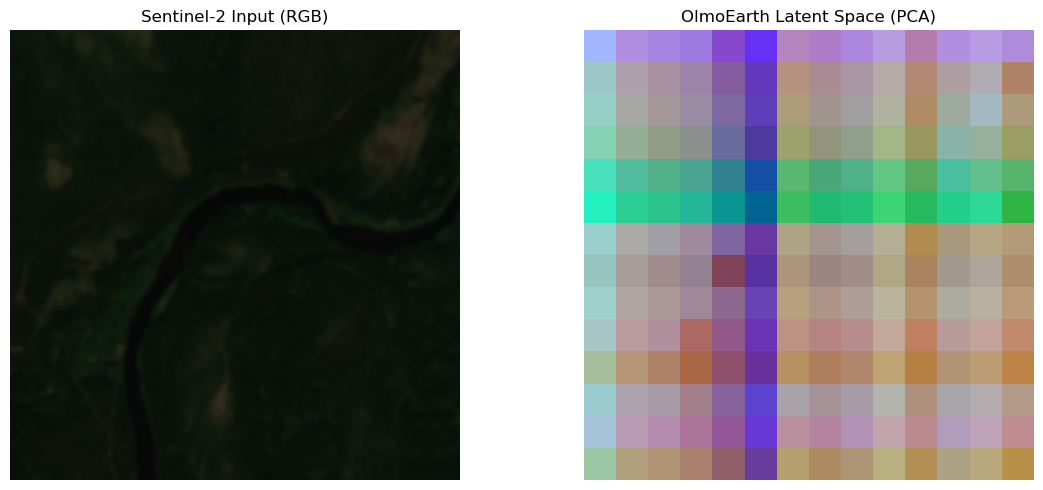

🚀 Visualization Complete.


In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from skimage.transform import resize
import torch
import os
import rasterio
import numpy as np
from olmoearth_pretrain.datatypes import MaskedOlmoEarthSample

# 1. DATA ANALYSIS: CLASS IMBALANCE
num_samples = min(50, len(df))
water_pixels, total_pixels = 0, 0

for i in range(num_samples):
    label_path = os.path.join(DATA_ROOT, df.iloc[i]['label_path'])
    with rasterio.open(label_path) as src:
        mask = src.read(1)
        water_pixels += np.sum(mask == 1)
        total_pixels += mask.size

print(f"✅ Class Imbalance: Water is {((water_pixels / total_pixels) * 100):.2f}% of pixels.")

# 2. PRE-PROCESS IMAGE
s2_path = os.path.join(DATA_ROOT, df.iloc[0]['s2_path_reprojected'])
with rasterio.open(s2_path) as src:
    img = src.read()
    img_resized = resize(img, (img.shape[0], 224, 224), anti_aliasing=True)
    img_transposed = np.transpose(img_resized, (1, 2, 0))
    input_tensor = torch.from_numpy(img_transposed).float().unsqueeze(0).unsqueeze(3)

# 3. INFERENCE
with torch.no_grad():
    timestamps = torch.tensor([[[15, 6, 2023]]]).to(input_tensor.device)
    sample = MaskedOlmoEarthSample(
        sentinel2_l2a=input_tensor,
        sentinel2_l2a_mask=torch.zeros_like(input_tensor),
        timestamps=timestamps
    )

    # The forward pass returns a tuple: 
    # (latent, decoded, latent_projected_and_pooled, reconstructed, extra_metrics)
    output_tuple = model(sample, patch_size=16)
    
    # ⚠️ FIX: Extract the latent TokenAndMasks structure and grab S2 embeddings
    latent = output_tuple[0]
    
    # shape: (Batch, H_patches, W_patches, Time, Band_Sets, D) -> e.g. (1, 14, 14, 1, x, 768)
    s2_tokens = latent.sentinel2_l2a  

# 4. PCA DIMENSIONALITY REDUCTION
# Average across Time and Band_Sets (dims 2 and 3 after grabbing Batch 0)
# Leaving us with (14, 14, 768)
spatial_tokens = s2_tokens[0].mean(dim=(2, 3)) 
tokens = spatial_tokens.reshape(14 * 14, -1).cpu().numpy()

pca = PCA(n_components=3)
pca_features = pca.fit_transform(tokens)

# Reshape to 14x14 grid
pca_grid = pca_features.reshape(14, 14, 3)
pca_grid = (pca_grid - pca_grid.min()) / (pca_grid.max() - pca_grid.min())

# 5. PLOT
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RGB Display (Bands 4, 3, 2) normalized
rgb = np.transpose(img_resized[[3, 2, 1], :, :], (1, 2, 0))
rgb = np.clip(rgb / (img_resized.max() if img_resized.max() > 0 else 1), 0, 1)

axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 Input (RGB)")
axes[0].axis('off')

axes[1].imshow(pca_grid, interpolation='nearest')
axes[1].set_title("OlmoEarth Latent Space (PCA)")
axes[1].axis('off')

plt.tight_layout()
plt.show()
print("🚀 Visualization Complete.")
